<a href="https://colab.research.google.com/github/Nivethika-hub/nivethika-codebooster-2026/blob/main/Day-3/mini_project3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
API_KEY ='b81f00d0660cef10842f8263367344a0'
BASE_URL='https://api.openweathermap.org/data/2.5/weather'
CITIES =['Mumbai','Delhi','Bangalore','Chennai','Hyderbad','Kolkata', 'Pune','Jaipur']
print(f'API configured for {len(CITIES)} cities')
print(f'Cities:{CITIES}')

API configured for 8 cities
Cities:['Mumbai', 'Delhi', 'Bangalore', 'Chennai', 'Hyderbad', 'Kolkata', 'Pune', 'Jaipur']


In [2]:
import requests

def fetch_weather(city, api_key):
  """
  Fetch current weather data for a given city.
  Returns a dictionary with weather metrics, or None on failure.
  """

  params = {
      'q': city,
      'appid': api_key,
      'units': 'metric'
  }

  try:
    response = requests.get(BASE_URL, params=params, timeout=10)
    response.raise_for_status() # Raises HTTPError for bad responses (4xx or 5xx)

    data = response.json()

    return {
        'city': city,
        'temperature': round(data['main']['temp'], 1),
        'feels_like': round(data['main']['feels_like'], 1),
        'humidity': data['main']['humidity'],
        'pressure': data['main']['pressure'],
        'wind_speed': data['wind']['speed'],
        'condition': data['weather'][0]['description'],
        'visibiilty': data['visibility']
    }

  except requests.exceptions.HTTPError as http_err:
    print(f'HTTP error occurred for {city}: {http_err}')
    return None
  except requests.exceptions.ConnectionError as conn_err:
    print(f'Connection error occurred for {city}: {conn_err}')
    return None
  except requests.exceptions.Timeout as timeout_err:
    print(f'Timeout error occurred for {city}: {timeout_err}')
    return None
  except requests.exceptions.RequestException as req_err:
    print(f'An error occurred during the request for {city}: {req_err}')
    return None
  except Exception as e:
    print(f'An unexpected error occurred for {city}: {e}')
    return None

In [3]:
import requests
import pandas as pd

weather_data = []

for city in CITIES:
  weather = fetch_weather(city, API_KEY)
  if weather:
    weather_data.append(weather)

df_weather = pd.DataFrame(weather_data)
display(df_weather)

HTTP error occurred for Hyderbad: 404 Client Error: Not Found for url: https://api.openweathermap.org/data/2.5/weather?q=Hyderbad&appid=b81f00d0660cef10842f8263367344a0&units=metric


,city,temperature,feels_like,humidity,pressure,wind_speed,condition,visibiilty
0,Mumbai,31.0,37.6,70,1010,4.63,haze,4000
1,Delhi,29.1,30.8,58,1001,5.14,overcast clouds,3500
2,Bangalore,23.7,24.2,83,1014,4.63,broken clouds,6000
3,Chennai,31.8,38.8,85,1010,5.14,few clouds,6000
4,Kolkata,26.0,26.0,83,1007,0.00,haze,3200
5,Pune,27.6,29.6,67,1011,5.28,clear sky,10000
6,Jaipur,35.6,35.1,28,1000,7.72,haze,3500


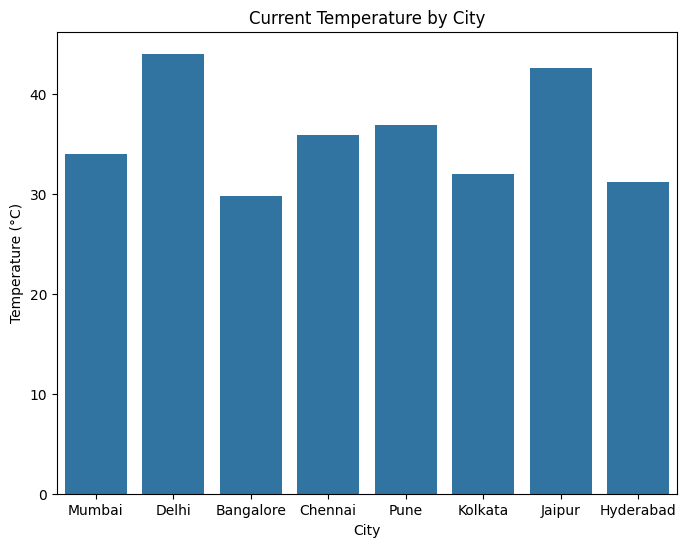

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8, 6))
sns.barplot(x='city', y='temperature', data=df_weather)
plt.title('Current Temperature by City')
plt.xlabel('City')
plt.ylabel('Temperature (°C)')
plt.show()